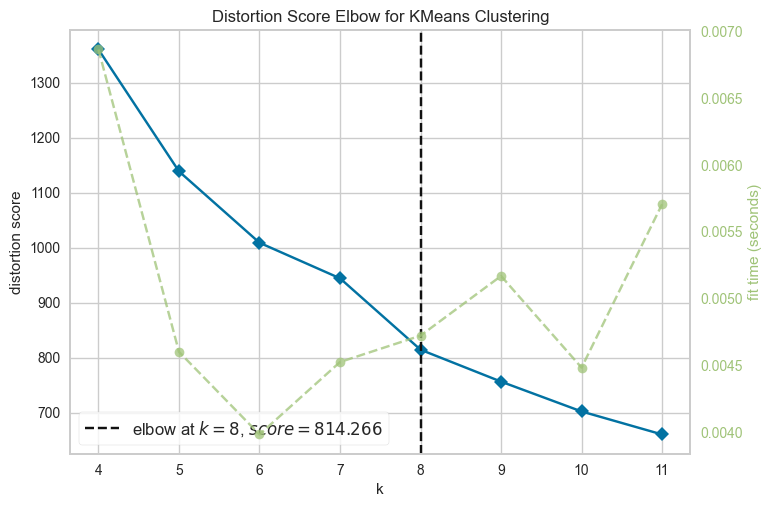

Best k = 8

=== STATION TO CLUSTER MAPPING ===
Station 2733.03 → Cluster 3
Station 2782.02 → Cluster 3
Station 2821.05 → Cluster 3
Station 2832.03 → Cluster 3
Station 2872.02 → Cluster 3
Station 2883.03 → Cluster 3
Station 2912.08 → Cluster 3
Station 2923.01 → Cluster 3
Station 2932.01 → Cluster 3
Station 2932.03 → Cluster 3
Station 2951.05 → Cluster 3
Station 2961.05 → Cluster 3
Station 2971.02 → Cluster 3
Station 3000.08 → Cluster 3
Station 3007.05 → Cluster 3
Station 3011.03 → Cluster 3
Station 3019.02 → Cluster 3
Station 3019.03 → Cluster 3
Station 3038.08 → Cluster 3
Station 3046.03 → Cluster 3
Station 3050.03 → Cluster 3
Station 3056.05 → Cluster 3
Station 3084.05 → Cluster 3
Station 3090.06 → Cluster 3
Station 3093.07 → Cluster 3
Station 3117.05 → Cluster 3
Station 3125.09 → Cluster 3
Station 3129.08 → Cluster 3
Station 3135.04 → Cluster 3
Station 3138.09 → Cluster 3
Station 3161.02 → Cluster 3
Station 3166.03 → Cluster 3
Station 3169.07 → Cluster 3
Station 3178.02 → Cluster 3
S

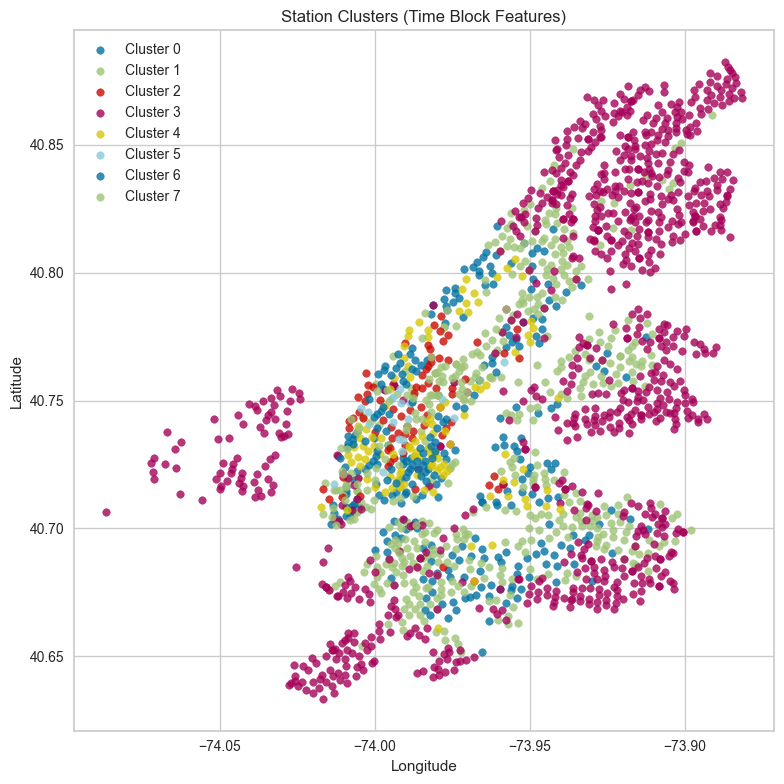

===== CLUSTER SIZES =====
0    222
1    407
2     75
3    921
4    106
5     18
6     63
7     95
Name: count, dtype: int64

===== CLEAN CLUSTER FEATURE STATS =====

               h0_5                    h6_11                    h12_17  \
               mean         std         mean          std         mean   
cluster                                                                  
0        133.362613   45.998686   673.371622   221.046877  1223.152402   
1         75.914824   30.619857   352.599918   170.757376   612.929156   
2        233.404444   64.160080  2416.953333   553.991649  3286.951111   
3         20.330257   17.148517    71.903547    74.163587   133.994752   
4        220.795597   48.279884  1107.834906   316.164602  2168.047170   
5        417.157407  140.117452  3602.425926  1124.343090  5127.453704   
6        381.312169   64.973799  1606.576720   397.278906  3167.166667   
7        113.247368   42.944628  1571.691228   400.394880  1812.015789   

                   

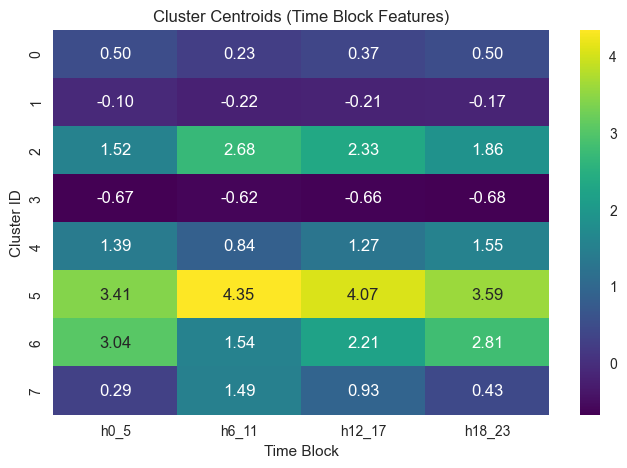


=== Unscaled Cluster Centroids (Real Inflow Values) ===
         h0_5        h6_11       h12_17       h18_23
0  133.362613   673.371622  1223.152402   935.680180
1   75.914824   352.599918   612.929156   461.323505
2  233.404444  2416.953333  3286.951111  1902.882222
3   20.330257    71.903547   133.994752   101.576185
4  220.795597  1107.834906  2168.047170  1682.133648
5  417.157407  3602.425926  5127.453704  3129.842593
6  381.312169  1606.576720  3167.166667  2573.423280
7  113.247368  1571.691228  1812.015789   886.126316


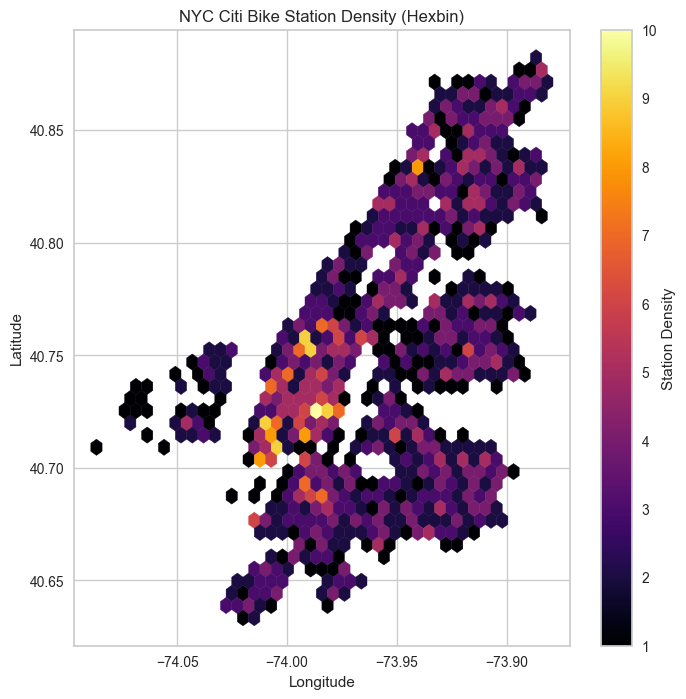

In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

from yellowbrick.cluster import KElbowVisualizer 
df = pd.read_parquet('/Users/manasvinisaripalli/cs210-citibike-1/data/citibike_2022_master.parquet')
# print(df.head())

# def get_season(month):
#     if month in [1,2,3]:
#         return "winter"
#     elif month in [4,5,6]:
#         return "spring"
#     elif month in [7,8,9]:
#         return "summer"
#     else:
#         return "fall"

# df['season'] = df['month'].apply(get_season)

# season_results = {}
# station_cluster_maps = {} 

# df['in_flow'] = 1
# df.rename(columns={'end_station_id': 'station_id'}, inplace=True)

# for season in df['season'].unique():
#     print(f"Processing {season}")
    
#     season_df = df[df['season'] == season]

#     # station x hour inflow matrix
#     pivot = season_df.pivot_table(
#         index='station_id',
#         columns='hour',
#         values='in_flow',
#         aggfunc='sum',
#         fill_value=0
#     )


#     # ensure all 24 hours exist
#     pivot = pivot.reindex(columns=range(24), fill_value=0)
#     pivot.columns = [f'hour_{i}' for i in range(24)]

#     # time block features
#     pivot['h0_5'] = pivot[[f'hour_{i}' for i in range(0,6)]].mean(axis=1)
#     pivot['h6_11'] = pivot[[f'hour_{i}' for i in range(6,12)]].mean(axis=1)
#     pivot['h12_17'] = pivot[[f'hour_{i}' for i in range(12,18)]].mean(axis=1)
#     pivot['h18_23'] = pivot[[f'hour_{i}' for i in range(18,24)]].mean(axis=1)

#     X = pivot[['h0_5','h6_11','h12_17','h18_23']]

#     # scale
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)

#     # choose k (elbow method)
#     model = KMeans(random_state=42)
#     visualizer = KElbowVisualizer(model, k=(4,12))
#     visualizer.fit(X_scaled)
#     visualizer.show()

#     best_k = visualizer.elbow_value_ or 5
#     print("Best k:", best_k)

#     # fit kmeans
#     kmeans = KMeans(n_clusters=best_k, random_state=42)
#     clusters = kmeans.fit_predict(X_scaled)
#     # ---- CLUSTER CENTROIDS FOR THIS SEASON ----editthis
#     centroids = pd.DataFrame(
#         kmeans.cluster_centers_,
#         columns=['h0_5','h6_11','h12_17','h18_23']
#     )

#     # reverse the StandardScaler transform
#     centroids_unscaled = pd.DataFrame(
#         scaler.inverse_transform(centroids),
#         columns=centroids.columns
#     )
#     # store results
#     pivot['cluster'] = clusters
#     season_results[season] = pivot[['cluster']]

#     mapping = dict(zip(pivot.index, pivot['cluster']))
#     station_cluster_maps[season] = dict(sorted(mapping.items()))
# # final output example
# # print(season_results['winter'].head())
# # print("\nWinter mapping:")
# # print(station_cluster_maps['winter'])

# # print("\nSpring mapping:")
# # print(station_cluster_maps['spring'])

# # print(X.describe())
# for season in ["winter", "spring", "summer", "fall"]:
#     print(f"\n=== {season.upper()} CLUSTER MAPPING ===")
    
#     mapping = station_cluster_maps.get(season, {})
    
#     for station_id, cluster_id in sorted(mapping.items()):
#         print(f"Station {station_id:>6}  →  Cluster {cluster_id}")


# colors = plt.cm.tab10  # up to 10 clusters

# for season in ["winter", "spring", "summer", "fall"]:
#     print(f"Plotting {season}...")

#     # get mapping for this season
#     mapping = station_cluster_maps[season]

#     # filter df
#     season_df = df[df["season"] == season].copy()

#     # attach cluster labels
#     season_df["cluster"] = season_df["station_id"].map(mapping)

#     # drop stations without cluster assignment
#     season_df = season_df.dropna(subset=["cluster"])

#     # plot
#     plt.figure(figsize=(8, 8))
#     for cluster_id in sorted(season_df["cluster"].unique()):
#         subset = season_df[season_df["cluster"] == cluster_id]
#         plt.scatter(
#             subset["long"],
#             subset["lat"],
#             s=30,
#             color=colors(int(cluster_id) % 10),
#             label=f"Cluster {cluster_id}",
#             alpha=0.8
#         )

#     plt.title(f"{season.capitalize()} Station Clusters")
#     plt.xlabel("Longitude")
#     plt.ylabel("Latitude")
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()



# for season in ["winter", "spring", "summer", "fall"]:
#     mapping = station_cluster_maps[season]
#     season_df = df[df["season"] == season].copy()
#     season_df["cluster"] = season_df["station_id"].map(mapping)
#     season_df = season_df.dropna(subset=["cluster"])

#     plt.figure(figsize=(8,8))

#     plt.hexbin(
#         season_df["long"],
#         season_df["lat"],
#         gridsize=40,
#         cmap="inferno",
#         mincnt=1
#     )
#     plt.colorbar(label="Station Density")

#     plt.title(f"{season.capitalize()} — Station Density (Hexbin)")
#     plt.xlabel("Longitude")
#     plt.ylabel("Latitude")
#     plt.show()

#pivot table
pivot = df.pivot_table(
    index='station_id',
    columns='hour',
    values='in_flow',
    aggfunc='sum',
    fill_value=0
)

pivot = pivot.reindex(columns=range(24), fill_value=0)
pivot.columns = [f'hour_{i}' for i in range(24)]

# compute 4 time-block features
pivot['h0_5']   = pivot[[f'hour_{i}' for i in range(0,6)]].mean(axis=1)
pivot['h6_11']  = pivot[[f'hour_{i}' for i in range(6,12)]].mean(axis=1)
pivot['h12_17'] = pivot[[f'hour_{i}' for i in range(12,18)]].mean(axis=1)
pivot['h18_23'] = pivot[[f'hour_{i}' for i in range(18,24)]].mean(axis=1)

X = pivot[['h0_5','h6_11','h12_17','h18_23']]

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# elbow method 
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(4,12))
visualizer.fit(X_scaled)
visualizer.show()

best_k = visualizer.elbow_value_
print("Best k =", best_k)

# fit KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# final mapping: station_id → cluster_id
station_cluster_map = dict(zip(X.index, clusters))

print("\n=== STATION TO CLUSTER MAPPING ===")
for sid, cid in station_cluster_map.items():
    print(f"Station {sid} → Cluster {cid}")

# fluster Map (lat/long scatter)
df_clusters = df[['station_id','lat','long']].drop_duplicates()
df_clusters['cluster'] = df_clusters['station_id'].map(station_cluster_map)

plt.figure(figsize=(8,8))
for cid in sorted(df_clusters['cluster'].unique()):
    subset = df_clusters[df_clusters['cluster'] == cid]
    plt.scatter(subset['long'], subset['lat'], s=30, label=f"Cluster {cid}", alpha=0.8)

plt.title("Station Clusters (Time Block Features)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# heatmap of cluster centroids
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['h0_5','h6_11','h12_17','h18_23']
)

centroids_unscaled = pd.DataFrame(
    scaler.inverse_transform(centroids),
    columns=centroids.columns
)



cluster_sizes = pd.Series(clusters).value_counts().sort_index()
print("===== CLUSTER SIZES =====")
print(cluster_sizes)


df_stats = X.copy()
df_stats['cluster'] = clusters

# cluster_stats = df_stats.groupby('cluster').describe()
# print("===== CLUSTER FEATURE STATS =====")
# print(cluster_stats)
cluster_summary = df_stats.groupby("cluster").agg(["mean", "std"])
print("\n===== CLEAN CLUSTER FEATURE STATS =====\n")
print(cluster_summary)



df_geo = df[['station_id','lat','long']].drop_duplicates()
df_geo['cluster'] = df_geo['station_id'].map(station_cluster_map)

geo_stats = df_geo.groupby('cluster')[['lat','long']].mean()
print("===== CLUSTER GEOGRAPHIC STATS =====")
print(geo_stats)

cluster_demand = centroids_unscaled.sum(axis=1).sort_values(ascending=False)
print("\nHighest Demand cluster to Lowest Demand clusters based on inflow")
print(cluster_demand)


# 8. Heatmap of cluster centroids (scaled)
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['h0_5','h6_11','h12_17','h18_23']
)

plt.figure(figsize=(8,5))
sns.heatmap(centroids, cmap="viridis", annot=True, fmt=".2f")
plt.title("Cluster Centroids (Time Block Features)")
plt.xlabel("Time Block")
plt.ylabel("Cluster ID")
plt.show()

# 9. Unscaled centroids (real inflow values)
centroids_unscaled = pd.DataFrame(
    scaler.inverse_transform(centroids),
    columns=centroids.columns
)

print("\n=== Unscaled Cluster Centroids (Real Inflow Values) ===")
print(centroids_unscaled)

plt.figure(figsize=(8,8))

plt.hexbin(
    df_clusters["long"],
    df_clusters["lat"],
    gridsize=40,        # smaller = more detail
    cmap="inferno",
    mincnt=1
)

plt.colorbar(label="Station Density")
plt.title("NYC Citi Bike Station Density (Hexbin)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()